# LoRA Implementation

Add your HuggingFace token as a Kaggle secret:
→ Kaggle notebook → Add-ons → Secrets → Add Secret
→ Name: HF_TOKEN, Value: your HuggingFace token

In [1]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — Setup + verify GPU
# ═══════════════════════════════════════════════════════════════════
import torch, os

# load HF token from Kaggle secrets
from kaggle_secrets import UserSecretsClient
os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB")
print(f"PyTorch: {torch.__version__}")

GPU: Tesla T4
VRAM: 15.6GB
PyTorch: 2.10.0+cu128


In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — Install deps
# ═══════════════════════════════════════════════════════════════════
!pip install -q transformers datasets accelerate matplotlib tiktoken
print("Done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.8 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whic

In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — LoRALinear from scratch
# This is YOUR implementation — no PEFT library
# ═══════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class LoRALinear(nn.Module):
    """
    Drop-in replacement for nn.Linear with LoRA adapters.

    Standard linear:  output = x @ W.T
    With LoRA:        output = x @ W.T + (x @ A.T @ B.T) * scaling

    W is frozen — only A and B are trained.
    At init B=0 so output = x @ W.T exactly (stable start).

    Args:
        in_features:  same as nn.Linear
        out_features: same as nn.Linear
        r:            rank — controls adapter size
                      r=1 → fewest params
                      r=8 → sweet spot for most tasks
                      r=32 → approaches full fine-tune quality
        lora_alpha:   scaling hyperparameter
                      actual scaling = alpha/r
                      keeps update magnitude stable across ranks
        dropout:      dropout on LoRA input path only
    """
    def __init__(self,
                 in_features: int,
                 out_features: int,
                 r: int = 8,
                 lora_alpha: int = 16,
                 dropout: float = 0.05):
        super().__init__()
        self.r          = r
        self.lora_alpha = lora_alpha
        self.scaling    = lora_alpha / r

        # frozen base weight — same shape as nn.Linear
        # requires_grad=False: no gradient computed, not updated by optimizer
        self.weight = nn.Parameter(
            torch.empty(out_features, in_features),
            requires_grad=False
        )
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

        # trainable LoRA matrices
        # A: kaiming init — needs gradient signal immediately
        # B: zero init   — ensures BA=0 at start → output = base
        self.A = nn.Parameter(torch.empty(r, in_features))
        self.B = nn.Parameter(torch.zeros(out_features, r))
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # frozen base path
        base = F.linear(x, self.weight)

        # trainable LoRA path
        # x: [B, T, in]
        # x @ A.T → [B, T, r]
        # @ B.T   → [B, T, out]
        lora = F.linear(F.linear(self.dropout(x), self.A), self.B)

        return base + lora * self.scaling

    def extra_repr(self):
        return (f"in={self.weight.shape[1]}, out={self.weight.shape[0]}, "
                f"r={self.r}, alpha={self.lora_alpha}, "
                f"scaling={self.scaling:.3f}")


def merge_lora_into_base(model):
    """
    Merge trained LoRA adapters into base weights.
    After merge: model is identical in structure to original —
    zero extra inference latency.

    W_merged = W + B @ A * scaling
    """
    n = 0
    for module in model.modules():
        if not isinstance(module, LoRALinear):
            continue
        with torch.no_grad():
            # B: [out, r], A: [r, in] → B@A: [out, in] = same shape as W
            delta = (module.B @ module.A) * module.scaling
            module.weight.data.add_(delta)
            # zero adapters so they don't contribute twice
            module.A.data.zero_()
            module.B.data.zero_()
        n += 1
    print(f"Merged {n} LoRA adapters into base weights")
    return model


def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# ── sanity tests ──────────────────────────────────────────────────
print("Testing LoRALinear...")

torch.manual_seed(0)
base_linear = nn.Linear(64, 128, bias=False)
lora_linear = LoRALinear(64, 128, r=8, lora_alpha=16)
lora_linear.weight.data = base_linear.weight.data.clone()

x = torch.randn(2, 10, 64)

# test 1: output matches at init (B=0)
diff = (base_linear(x) - lora_linear(x)).abs().max().item()
assert diff < 1e-5, f"Mismatch at init: {diff}"
print(f"✓ Output matches nn.Linear at init (diff={diff:.2e})")

# test 2: W frozen, A and B trainable
trainable = [n for n,p in lora_linear.named_parameters() if p.requires_grad]
frozen    = [n for n,p in lora_linear.named_parameters() if not p.requires_grad]
assert trainable == ['A', 'B'] and frozen == ['weight']
print(f"✓ Trainable: {trainable} | Frozen: {frozen}")

# test 3: correct parameter reduction
lora_params = sum(p.numel() for p in lora_linear.parameters() if p.requires_grad)
full_params  = 64 * 128
print(f"✓ LoRA params: {lora_params:,} vs full: {full_params:,} ({100*lora_params/full_params:.1f}%)")

# test 4: gradients flow to A and B only
lora_linear(x).sum().backward()
assert lora_linear.A.grad is not None and lora_linear.B.grad is not None
assert lora_linear.weight.grad is None
print(f"✓ Gradients: A={lora_linear.A.grad.norm():.3f}, B={lora_linear.B.grad.norm():.3f}, W=None")

print("\nAll tests passed ✓")

Testing LoRALinear...
✓ Output matches nn.Linear at init (diff=0.00e+00)
✓ Trainable: ['A', 'B'] | Frozen: ['weight']
✓ LoRA params: 1,536 vs full: 8,192 (18.8%)
✓ Gradients: A=0.000, B=164.268, W=None

All tests passed ✓


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — Load LLaMA-3.2-1B and apply LoRA
# ═══════════════════════════════════════════════════════════════════
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

MODEL_ID = "meta-llama/Llama-3.2-1B"
device   = "cuda"

print(f"Loading {MODEL_ID}...")
print("(~2GB download, takes ~2 mins on first run)")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=os.environ["HF_TOKEN"])
model     = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype = torch.float16,  # FP16 to fit on T4
    token       = os.environ["HF_TOKEN"],
)
model = model.to(device)

total, trainable = count_parameters(model)
print(f"\nModel loaded:")
print(f"  Total params:     {total/1e6:.0f}M")
print(f"  VRAM used:        {torch.cuda.memory_allocated()/1e9:.1f}GB")

# inspect architecture — shows which layers to target
print("\nLayer names (first block):")
for name, module in model.named_modules():
    if "layers.0" in name and isinstance(module, nn.Linear):
        print(f"  {name}: {module.in_features} → {module.out_features}")

Loading meta-llama/Llama-3.2-1B...
(~2GB download, takes ~2 mins on first run)


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]


Model loaded:
  Total params:     1236M
  VRAM used:        2.5GB

Layer names (first block):
  model.layers.0.self_attn.q_proj: 2048 → 2048
  model.layers.0.self_attn.k_proj: 2048 → 512
  model.layers.0.self_attn.v_proj: 2048 → 512
  model.layers.0.self_attn.o_proj: 2048 → 2048
  model.layers.0.mlp.gate_proj: 2048 → 8192
  model.layers.0.mlp.up_proj: 2048 → 8192
  model.layers.0.mlp.down_proj: 8192 → 2048


In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — apply_lora() for HuggingFace models
# Replaces target Linear layers with our LoRALinear
# ═══════════════════════════════════════════════════════════════════

def apply_lora_to_model(model, target_modules, r=8, lora_alpha=16, dropout=0.05):
    """
    Walk model and replace named Linear layers with LoRALinear.

    Args:
        model:          any nn.Module (works on HuggingFace models)
        target_modules: list of layer name substrings to replace
                        for LLaMA: ["q_proj", "v_proj"] or add k_proj, o_proj
        r:              LoRA rank
        lora_alpha:     LoRA scaling

    Returns:
        model: modified in-place
        n_replaced: count of replaced layers
    """
    n_replaced = 0

    for name, module in model.named_modules():
        # skip if name doesn't match any target
        if not any(t in name for t in target_modules):
            continue
        if not isinstance(module, nn.Linear):
            continue

        # navigate to parent module
        parts  = name.split('.')
        parent = model
        for part in parts[:-1]:
            parent = getattr(parent, part)
        attr = parts[-1]

        old = getattr(parent, attr)

        # build LoRALinear with same dimensions
        new = LoRALinear(
            in_features  = old.in_features,
            out_features = old.out_features,
            r            = r,
            lora_alpha   = lora_alpha,
            dropout      = dropout,
        )

        # copy pretrained weight into frozen base
        new.weight.data = old.weight.data.clone().cpu().float()

        # replace
        setattr(parent, attr, new)
        n_replaced += 1

    return model, n_replaced


def freeze_base_model(model):
    """
    Freeze all parameters except LoRA adapters.
    Ensures only A and B matrices are updated during training.
    """
    for name, param in model.named_parameters():
        if 'lora' in name.lower() or name.endswith('.A') or name.endswith('.B'):
            param.requires_grad = True
        else:
            param.requires_grad = False

    # unfreeze A and B specifically in LoRALinear layers
    for module in model.modules():
        if isinstance(module, LoRALinear):
            module.A.requires_grad = True
            module.B.requires_grad = True
            module.weight.requires_grad = False


# apply LoRA — start with q_proj and v_proj (standard choice)
# these are the most impactful for instruction following
TARGET_MODULES = ["q_proj", "v_proj"]
RANK = 8

model, n_replaced = apply_lora_to_model(
    model,
    target_modules = TARGET_MODULES,
    r          = RANK,
    lora_alpha = RANK * 2,    # alpha = 2*r is a common default
)

freeze_base_model(model)

total, trainable = count_parameters(model)
print(f"LoRA applied to {n_replaced} layers")
print(f"Total params:     {total/1e6:.1f}M")
print(f"Trainable params: {trainable/1e3:.1f}k  ({100*trainable/total:.3f}%)")
print(f"VRAM after LoRA:  {torch.cuda.memory_allocated()/1e9:.1f}GB")

LoRA applied to 32 layers
Total params:     1236.7M
Trainable params: 852.0k  (0.069%)
VRAM after LoRA:  2.3GB


In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — Dataset: Alpaca formatted for LLaMA chat template
# ═══════════════════════════════════════════════════════════════════
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader

print("Loading Alpaca...")
alpaca  = load_dataset("tatsu-lab/alpaca", split="train")
n_val   = 500      # fixed val set
n_train = len(alpaca) - n_val

class AlpacaDataset(Dataset):
    def __init__(self, data, tokenizer, max_seq=256):
        self.examples = []
        self.max_seq  = max_seq
        skipped = 0

        for item in data:
            tokens, mask = self._format(item, tokenizer)
            if tokens is None:
                skipped += 1
                continue
            self.examples.append((tokens, mask))

        print(f"  {len(self.examples):,} examples ({skipped:,} skipped)")

    def _format(self, item, tokenizer):
        # use LLaMA chat-style format
        prompt   = f"<|user|>\n{item['instruction']}"
        if item['input'].strip():
            prompt += f"\n{item['input']}"
        prompt  += "\n<|assistant|>\n"
        response = item['output'] + tokenizer.eos_token

        prompt_ids   = tokenizer.encode(prompt,   add_special_tokens=True)
        response_ids = tokenizer.encode(response, add_special_tokens=False)
        tokens       = prompt_ids + response_ids

        if len(tokens) > self.max_seq:
            return None, None

        # 0 = ignore prompt, 1 = train on response
        mask = [0]*len(prompt_ids) + [1]*len(response_ids)
        return tokens, mask

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        tokens, mask = self.examples[idx]
        tokens = torch.tensor(tokens, dtype=torch.long)
        mask   = torch.tensor(mask,   dtype=torch.long)
        return tokens[:-1], tokens[1:], mask[1:]


def collate(batch):
    xs, ys, ms = zip(*batch)
    L  = max(x.size(0) for x in xs)
    xp = torch.zeros(len(xs), L, dtype=torch.long)
    yp = torch.full((len(ys), L), -1, dtype=torch.long)
    mp = torch.zeros(len(ms), L, dtype=torch.long)
    for i,(x,y,m) in enumerate(zip(xs,ys,ms)):
        T = x.size(0)
        xp[i,:T] = x; yp[i,:T] = y; mp[i,:T] = m
    return xp, yp, mp


tokenizer.pad_token = tokenizer.eos_token

print("Building datasets...")
train_ds = AlpacaDataset(alpaca.select(range(n_train)),         tokenizer)
val_ds   = AlpacaDataset(alpaca.select(range(n_train, len(alpaca))), tokenizer)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,
                          collate_fn=collate, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False,
                          collate_fn=collate, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Loading Alpaca...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Building datasets...
  50,759 examples (743 skipped)
  489 examples (11 skipped)
Train batches: 12690
Val batches:   123


In [7]:
# CELL 0 — run this first, then restart kernel
!pip install -q torch==2.1.0+cu118 torchvision torchaudio \
    --index-url https://download.pytorch.org/whl/cu118

ERROR: Could not find a version that satisfies the requirement torch==2.1.0+cu118 (from versions: 2.2.0+cu118, 2.2.1+cu118, 2.2.2+cu118, 2.3.0+cu118, 2.3.1+cu118, 2.4.0+cu118, 2.4.1+cu118, 2.5.0+cu118, 2.5.1+cu118, 2.6.0+cu118, 2.7.0+cu118, 2.7.1+cu118)
ERROR: No matching distribution found for torch==2.1.0+cu118


In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — LoRA training loop + rank ablations
# ═══════════════════════════════════════════════════════════════════
from torch.cuda.amp import GradScaler, autocast
import time, math, copy

def masked_ce(logits, targets, mask):
    B, T, V = logits.shape
    tgt = targets.clone()
    tgt[mask == 0] = -1
    return F.cross_entropy(logits.view(-1,V), tgt.view(-1), ignore_index=-1)


def run_lora_ablation(base_model, tokenizer, r, steps=300):
    """
    Run one LoRA ablation: apply rank r, train for N steps,
    return val losses for plotting.
    """
    print(f"\n{'─'*50}")
    print(f"LoRA r={r} | alpha={r*2} | steps={steps}")

    # deep copy base model so each run starts fresh
    m = copy.deepcopy(base_model)
    m, n = apply_lora_to_model(
        m, TARGET_MODULES, r=r, lora_alpha=r*2
    )
    freeze_base_model(m)
    m = m.to(device)

    total, trainable = count_parameters(m)
    print(f"Trainable: {trainable:,} / {total/1e6:.0f}M ({100*trainable/total:.3f}%)")

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, m.parameters()),
        lr=2e-4, weight_decay=0.01
    )
    scaler  = GradScaler()
    dtype   = torch.float16
    history = []   # (step, val_loss)

    m.train()
    t0   = time.time()
    step = 0

    for x, y, mask in train_loader:
        if step >= steps:
            break

        x, y, mask = x.to(device), y.to(device), mask.to(device)

        optimizer.zero_grad(set_to_none=True)
        with autocast(dtype=dtype):
            out  = m(input_ids=x).logits
            loss = masked_ce(out, y, mask)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        if step % 50 == 0:
            # eval
            m.eval()
            v_losses = []
            with torch.no_grad():
                for i, (vx,vy,vm) in enumerate(val_loader):
                    if i >= 10: break
                    vx,vy,vm = vx.to(device),vy.to(device),vm.to(device)
                    with autocast(dtype=dtype):
                        vl = m(input_ids=vx).logits
                        v_losses.append(masked_ce(vl, vy, vm).item())
            val_loss = sum(v_losses)/len(v_losses)
            history.append((step, val_loss))
            elapsed = time.time() - t0
            print(f"  step {step:3d} | train {loss.item():.4f} | val {val_loss:.4f} | {elapsed:.0f}s")
            m.train()

        step += 1

    # free GPU memory between runs
    del m
    torch.cuda.empty_cache()

    return history, trainable


# ── run all ablations ─────────────────────────────────────────────
# load a clean copy of the base model for each run
print("Loading clean base model for ablations...")
base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype = torch.float16,
    token       = os.environ["HF_TOKEN"],
)

ablation_results = {}

for r in [4, 8, 16, 32]:
    history, n_params = run_lora_ablation(base, tokenizer, r=r, steps=300)
    ablation_results[r] = {
        'history':  history,
        'n_params': n_params,
    }
    torch.cuda.empty_cache()

print("\nAll ablations complete!")

Loading clean base model for ablations...


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]


──────────────────────────────────────────────────
LoRA r=4 | alpha=8 | steps=300
Trainable: 425,984 / 1236M (0.034%)


/tmp/ipykernel_58/827853205.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = GradScaler()
/tmp/ipykernel_58/827853205.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=dtype):
/tmp/ipykernel_58/827853205.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=dtype):


  step   0 | train 1.4844 | val 1.7726 | 3s
  step  50 | train 1.0485 | val 1.4414 | 13s
  step 100 | train 1.4162 | val 1.4179 | 23s
  step 150 | train 0.8700 | val 1.4099 | 34s
  step 200 | train 1.6724 | val 1.3960 | 44s
  step 250 | train 1.8077 | val 1.3848 | 55s

──────────────────────────────────────────────────
LoRA r=8 | alpha=16 | steps=300
Trainable: 851,968 / 1237M (0.069%)
  step   0 | train 1.6366 | val 1.7674 | 1s
  step  50 | train 1.4078 | val 1.4350 | 12s
  step 100 | train 1.0064 | val 1.3923 | 24s
  step 150 | train 1.3923 | val 1.3845 | 35s
  step 200 | train 2.1568 | val 1.3887 | 46s
  step 250 | train 1.2335 | val 1.3705 | 58s

──────────────────────────────────────────────────
LoRA r=16 | alpha=32 | steps=300
Trainable: 1,703,936 / 1238M (0.138%)
  step   0 | train 2.2233 | val 1.7588 | 1s
  step  50 | train 1.3493 | val 1.4109 | 13s
  step 100 | train 1.3232 | val 1.4009 | 24s
  step 150 | train 1.7486 | val 1.3804 | 35s
  step 200 | train 1.5616 | val 1.3817 |

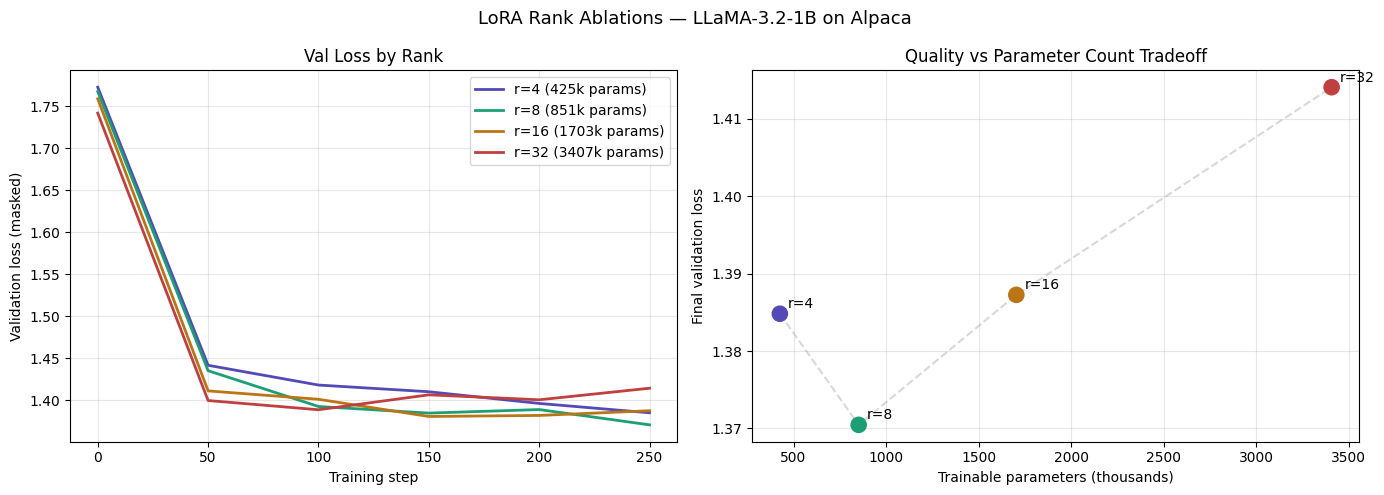

Saved: /kaggle/working/lora_ablations_llama.png


In [11]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — Plot results (goes in your README)
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

COLORS = {4: '#534AB7', 8: '#1D9E75', 16: '#BA7517', 32: '#C04040'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LoRA Rank Ablations — LLaMA-3.2-1B on Alpaca',
             fontsize=13, fontweight='500')

# plot 1 — val loss curves
ax1 = axes[0]
for r, data in ablation_results.items():
    if not data['history']: continue
    steps, vals = zip(*data['history'])
    n_k = data['n_params'] // 1000
    ax1.plot(steps, vals, label=f"r={r} ({n_k}k params)",
             color=COLORS[r], linewidth=2)

ax1.set_xlabel('Training step')
ax1.set_ylabel('Validation loss (masked)')
ax1.set_title('Val Loss by Rank')
ax1.legend()
ax1.grid(True, alpha=0.3)

# plot 2 — quality vs param count scatter
ax2 = axes[1]
ranks, final_losses, param_ks = [], [], []
for r, data in ablation_results.items():
    if not data['history']: continue
    ranks.append(r)
    final_losses.append(data['history'][-1][1])
    param_ks.append(data['n_params'] / 1000)

ax2.scatter(param_ks, final_losses, s=120, zorder=5,
            color=[COLORS[r] for r in ranks])
ax2.plot(param_ks, final_losses, '--', alpha=0.3, color='gray')
for i, r in enumerate(ranks):
    ax2.annotate(f"r={r}", (param_ks[i], final_losses[i]),
                 textcoords="offset points", xytext=(6,4), fontsize=10)

ax2.set_xlabel('Trainable parameters (thousands)')
ax2.set_ylabel('Final validation loss')
ax2.set_title('Quality vs Parameter Count Tradeoff')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/lora_ablations_llama.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /kaggle/working/lora_ablations_llama.png")

In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9 — Test inference: base vs LoRA fine-tuned
# ═══════════════════════════════════════════════════════════════════

# train a final r=8 model properly (more steps) for demo
print("Training final r=8 model for inference demo...")
final_model, _ = run_lora_ablation(base, tokenizer, r=8, steps=500)

# save
torch.save({
    'lora_state': {n: p for n,p in final_model[0].named_parameters() if p.requires_grad},
    'r': 8,
    'target_modules': TARGET_MODULES,
}, '/kaggle/working/llama_lora_r8.pt')

@torch.no_grad()
def generate(model, prompt, max_new=150, temperature=0.7):
    model.eval()
    inputs = tokenizer(
        f"<|user|>\n{prompt}\n<|assistant|>\n",
        return_tensors="pt"
    ).to(device)
    out = model.generate(
        **inputs,
        max_new_tokens  = max_new,
        temperature     = temperature,
        do_sample       = True,
        pad_token_id    = tokenizer.eos_token_id,
    )
    # decode only the new tokens
    new_tokens = out[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


prompts = [
    "Explain what machine learning is in simple terms.",
    "Write a short poem about autumn.",
    "What are three tips for learning a new language?",
]

print("=" * 60)
for prompt in prompts:
    print(f"User: {prompt}")
    print(f"Assistant: {generate(final_model[0], prompt)}")
    print("-" * 40)

Training final r=8 model for inference demo...

──────────────────────────────────────────────────
LoRA r=8 | alpha=16 | steps=500
Trainable: 851,968 / 1237M (0.069%)


/tmp/ipykernel_58/827853205.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = GradScaler()
/tmp/ipykernel_58/827853205.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=dtype):
/tmp/ipykernel_58/827853205.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=dtype):


  step   0 | train 2.5411 | val 1.7693 | 1s
  step  50 | train 1.5681 | val 1.4253 | 12s
  step 100 | train 1.1287 | val 1.3923 | 24s
  step 150 | train 1.1724 | val 1.3937 | 35s
  step 200 | train 1.1730 | val 1.3823 | 47s
  step 250 | train 1.5797 | val 1.3757 | 58s
  step 300 | train 1.2883 | val 1.3727 | 69s
  step 350 | train 0.7931 | val 1.3788 | 82s
  step 400 | train 1.9417 | val 1.3579 | 93s
  step 450 | train 1.1945 | val 1.3628 | 104s


AttributeError: 'tuple' object has no attribute 'named_parameters'